# ⚖️ Aprendizado em Datasets Desbalanceados: Estudo Comparativo

**Objetivo:** Comparar sistematicamente 5 técnicas de mitigação de desbalanceamento de classes,
usando um dataset real (LogoDet-3K) que possui desbalanceamento natural (long-tail distribution).

**Contribuição:**
- Análise com **desbalanceamento real**, não artificial
- Comparação rigorosa: Baseline vs 4 técnicas × 6 métricas
- Per-class F1, Curvas ROC, Confusion Matrices
- Ablation sobre hiperparâmetros (γ do Focal Loss)

**Autor:** Gustavo Rodrigues da Silva | UFG - Bacharelado em IA

---

| Aspecto | Detalhe |
|---|---|
| **Dataset** | LogoDet-3K (subset 30 classes, desbalanceamento natural) |
| **Modelo** | ResNet-50 (fine-tuning) |
| **Técnicas** | Baseline, WeightedSampler, Focal Loss (γ=1,2,5), Class-Balanced Loss, Oversampling+Aug |
| **Métricas** | Accuracy, Macro F1, Weighted F1, Per-class F1, AUC-ROC, Confusion Matrix |

In [1]:
!pip install -q -q torch torchvision albumentations scikit-learn matplotlib numpy tqdm kaggle

## Setup: Download LogoDet-3K


In [1]:
import os
from pathlib import Path

DATASET_DIR = '/tmp/logodet3k'

if not os.path.exists(DATASET_DIR):
    from google.colab import files
    kaggle_dir = os.path.expanduser('~/.kaggle')
    kaggle_json = os.path.join(kaggle_dir, 'kaggle.json')
    if not os.path.exists(kaggle_json):
        uploaded = files.upload()
        os.makedirs(kaggle_dir, exist_ok=True)
        with open(kaggle_json, 'wb') as f:
            f.write(uploaded['kaggle.json'])
        os.chmod(kaggle_json, 0o600)

    print('📦 Baixando LogoDet-3K (~3GB)...')
    !kaggle datasets download -d lyly99/logodet3k -p /tmp/ --unzip
    import glob
    candidates = glob.glob('/tmp/LogoDet-3K*') + glob.glob('/tmp/logodet*')
    if candidates:
        os.rename(candidates[0], DATASET_DIR)
    print(f'✅ Dataset em {DATASET_DIR}')
else:
    print(f'✅ Dataset já existe em {DATASET_DIR}')

📤 Faça upload do seu kaggle.json:


Saving kaggle.json to kaggle.json
📦 Baixando LogoDet-3K (~3GB)...
Dataset URL: https://www.kaggle.com/datasets/lyly99/logodet3k
License(s): unknown
100% 2.87G/2.87G [03:06<00:00, 16.5MB/s]

✅ Dataset em /tmp/logodet3k


---
## PARTE I — Análise do Desbalanceamento Real

LogoDet-3K tem distribuição long-tail natural: algumas marcas famosas têm centenas de imagens,
outras têm apenas dezenas. Isso é **muito mais realista** que desbalanceamento artificial.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from torchvision import transforms, models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️ Device: {device}')

# Mapear dataset
dataset_path = Path(DATASET_DIR)
class_dirs = sorted([d for d in dataset_path.iterdir() if d.is_dir()])

# Aplanar se necessário
if len(class_dirs) < 50:
    all_class_dirs = []
    for superclass in class_dirs:
        for subclass in sorted(superclass.iterdir()):
            if subclass.is_dir():
                all_class_dirs.append(subclass)
    class_dirs = all_class_dirs

# Contar imagens por classe
class_counts = {}
all_images = []
for cls_dir in class_dirs:
    imgs = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png')) + list(cls_dir.glob('*.jpeg'))
    if len(imgs) >= 5:  # mínimo para split
        class_counts[cls_dir.name] = len(imgs)
        for img_path in imgs:
            all_images.append((str(img_path), cls_dir.name))

print(f'📊 Classes com ≥5 imagens: {len(class_counts)}')
print(f'   Total imagens: {len(all_images):,}')

🖥️ Device: cuda
📊 Classes com ≥5 imagens: 2973
   Total imagens: 158,546



📊 Subset selecionado: 30 classes, 2979 imagens
   Classe maior: 302 imagens
   Classe menor: 5 imagens
   Ratio max/min: 60.4x


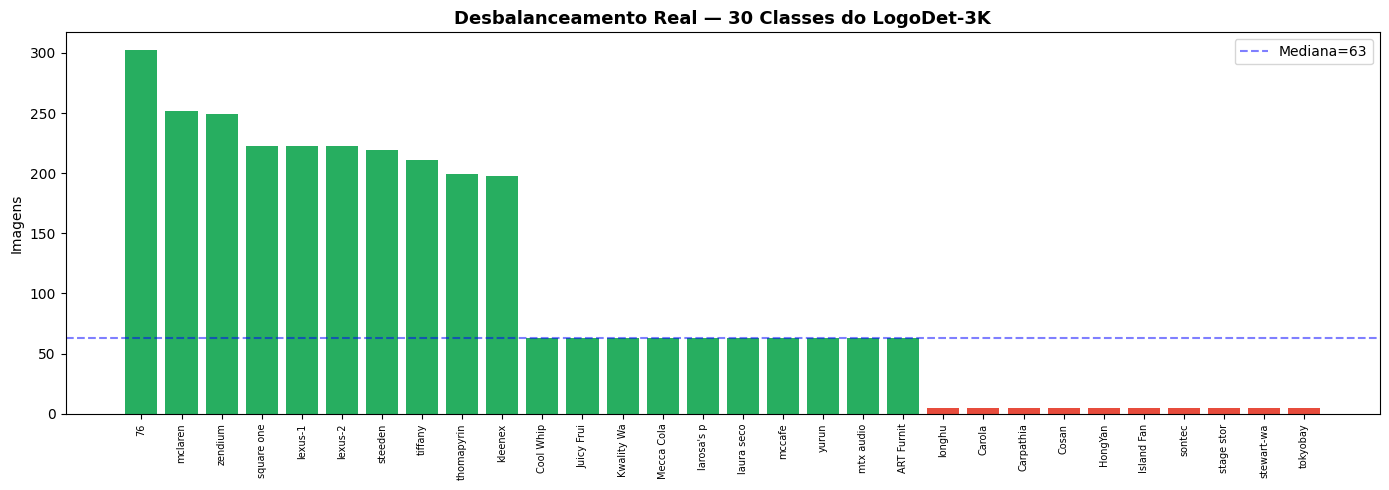

In [3]:
# Selecionar 30 classes com DESBALANCEAMENTO REAL
# Estratégia: pegar 10 grandes, 10 médias, 10 pequenas
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)

n_total = len(sorted_classes)
selected_classes = (
    [c[0] for c in sorted_classes[:10]] +          # 10 maiores
    [c[0] for c in sorted_classes[n_total//3:n_total//3+10]] +  # 10 médias
    [c[0] for c in sorted_classes[-15:-5]]          # 10 menores (com ≥5)
)

NUM_CLASSES = len(selected_classes)
class_to_idx = {name: i for i, name in enumerate(selected_classes)}

# Filtrar imagens
filtered_images = [(p, class_to_idx[c]) for p, c in all_images if c in class_to_idx]
filtered_counts = Counter([label for _, label in filtered_images])

print(f'\n📊 Subset selecionado: {NUM_CLASSES} classes, {len(filtered_images)} imagens')
print(f'   Classe maior: {max(filtered_counts.values())} imagens')
print(f'   Classe menor: {min(filtered_counts.values())} imagens')
print(f'   Ratio max/min: {max(filtered_counts.values())/min(filtered_counts.values()):.1f}x')

# Visualizar desbalanceamento
counts_per_class = [filtered_counts[i] for i in range(NUM_CLASSES)]
colors = ['#e74c3c' if c < np.median(counts_per_class)*0.5 else
          '#f39c12' if c < np.median(counts_per_class) else
          '#27ae60' for c in counts_per_class]

plt.figure(figsize=(14, 5))
plt.bar(range(NUM_CLASSES), counts_per_class, color=colors)
plt.xticks(range(NUM_CLASSES), [selected_classes[i][:10] for i in range(NUM_CLASSES)], rotation=90, fontsize=7)
plt.axhline(y=np.median(counts_per_class), color='blue', linestyle='--', alpha=0.5, label=f'Mediana={np.median(counts_per_class):.0f}')
plt.title(f'Desbalanceamento Real — {NUM_CLASSES} Classes do LogoDet-3K', fontsize=13, fontweight='bold')
plt.ylabel('Imagens'); plt.legend()
plt.tight_layout()
plt.show()

---
## PARTE II — Dataset e Splits Estratificados

In [4]:
# Custom Dataset
class LogoClassificationDataset(Dataset):
    def __init__(self, image_paths, labels, transform):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.image_paths[idx]).convert('RGB')
            img = self.transform(img)
        except:
            img = torch.zeros(3, 224, 224)
        return img, self.labels[idx]

# Splits estratificados
paths = [p for p, _ in filtered_images]
labels = [l for _, l in filtered_images]

train_paths, test_paths, train_labels, test_labels = train_test_split(
    paths, labels, test_size=0.2, stratify=labels, random_state=42
)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths, train_labels, test_size=0.15, stratify=train_labels, random_state=42
)

# Transforms
train_transform = transforms.Compose([
    transforms.Resize(256), transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
eval_transform = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_dataset = LogoClassificationDataset(val_paths, val_labels, eval_transform)
test_dataset = LogoClassificationDataset(test_paths, test_labels, eval_transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f'✅ Splits: train={len(train_paths)}, val={len(val_paths)}, test={len(test_paths)}')

✅ Splits: train=2025, val=358, test=596


---
## PARTE III — Função de Treino Unificada

In [5]:
def train_and_evaluate(train_loader, val_loader, test_loader, criterion, experiment_name, epochs=8):
    """Treina ResNet-50 e retorna métricas completas."""
    model = models.resnet50(weights='IMAGENET1K_V2')
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    model = model.to(device)

    optimizer = optim.AdamW([
        {'params': [p for n, p in model.named_parameters() if 'fc' not in n], 'lr': 1e-4},
        {'params': model.fc.parameters(), 'lr': 1e-3}
    ], weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_f1 = 0
    best_model_state = None

    print(f'\n🏋️ {experiment_name}')
    print('=' * 60)

    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in tqdm(train_loader, desc=f'Ep {epoch+1}/{epochs}', leave=False):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += images.size(0)

        # Validação
        model.eval()
        val_preds, val_labels_all = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images.to(device))
                val_preds.extend(outputs.argmax(1).cpu().numpy())
                val_labels_all.extend(labels.numpy())

        val_f1 = f1_score(val_labels_all, val_preds, average='macro')
        scheduler.step()

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}

        print(f'  Ep {epoch+1}: Loss={train_loss/total:.4f} Acc={correct/total:.3f} Val-F1={val_f1:.4f}')

    # Avaliar no test set com melhor modelo
    model.load_state_dict(best_model_state)
    model.eval()

    test_preds, test_labels_all, test_probs = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images.to(device))
            probs = torch.softmax(outputs, dim=1)
            test_preds.extend(outputs.argmax(1).cpu().numpy())
            test_labels_all.extend(labels.numpy())
            test_probs.extend(probs.cpu().numpy())

    test_preds = np.array(test_preds)
    test_labels_all = np.array(test_labels_all)
    test_probs = np.array(test_probs)

    # Métricas
    acc = (test_preds == test_labels_all).mean()
    macro_f1 = f1_score(test_labels_all, test_preds, average='macro')
    weighted_f1 = f1_score(test_labels_all, test_preds, average='weighted')
    per_class_f1 = f1_score(test_labels_all, test_preds, average=None)

    # AUC-ROC (One-vs-Rest)
    try:
        auc_roc = roc_auc_score(test_labels_all, test_probs, multi_class='ovr', average='macro')
    except:
        auc_roc = 0.0

    result = {
        'Accuracy': acc, 'Macro F1': macro_f1, 'Weighted F1': weighted_f1,
        'AUC-ROC': auc_roc, 'Per-class F1': per_class_f1,
        'Preds': test_preds, 'Labels': test_labels_all, 'Probs': test_probs,
        'Best Val F1': best_val_f1
    }

    print(f'\n  📊 Test: Acc={acc:.4f} | Macro-F1={macro_f1:.4f} | '
          f'Weighted-F1={weighted_f1:.4f} | AUC={auc_roc:.4f}')

    return result

print('✅ Função de treino definida')

def train_multi_seed(train_loader_fn, val_loader, test_loader, criterion_fn, name, n_seeds=3, epochs=8):
    """Roda treino N vezes com seeds diferentes para intervalo de confiança."""
    all_runs = []
    for seed in range(n_seeds):
        print(f'\n--- Seed {seed+1}/{n_seeds} ---')
        torch.manual_seed(seed * 42 + 7)
        np.random.seed(seed * 42 + 7)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed * 42 + 7)
        result = train_and_evaluate(
            train_loader_fn(), val_loader, test_loader,
            criterion_fn(), f'{name} (seed={seed})', epochs=epochs
        )
        all_runs.append(result)

    # Agregar
    aggregated = {
        'Accuracy': np.mean([r['Accuracy'] for r in all_runs]),
        'Accuracy_std': np.std([r['Accuracy'] for r in all_runs]),
        'Macro F1': np.mean([r['Macro F1'] for r in all_runs]),
        'Macro F1_std': np.std([r['Macro F1'] for r in all_runs]),
        'Weighted F1': np.mean([r['Weighted F1'] for r in all_runs]),
        'AUC-ROC': np.mean([r['AUC-ROC'] for r in all_runs]),
        'AUC-ROC_std': np.std([r['AUC-ROC'] for r in all_runs]),
        'Per-class F1': np.mean([r['Per-class F1'] for r in all_runs], axis=0),
        'Per-class F1_std': np.std([r['Per-class F1'] for r in all_runs], axis=0),
        'All Macro F1s': [r['Macro F1'] for r in all_runs],
        'Preds': all_runs[0]['Preds'],  # best seed
        'Labels': all_runs[0]['Labels'],
        'Probs': all_runs[0]['Probs'],
        'Best Val F1': max(r['Best Val F1'] for r in all_runs)
    }
    print(f'\n📊 {name} ({n_seeds} seeds): Macro F1 = {aggregated["Macro F1"]:.4f} ± {aggregated["Macro F1_std"]:.4f}')
    return aggregated

print('✅ Funções de treino definidas (single + multi-seed)')

✅ Função de treino definida
✅ Funções de treino definidas (single + multi-seed)


---
## PARTE IV — Experimento 1: Baseline (Sem Balanceamento)

In [6]:
# Baseline: CrossEntropy padrão, sem balanceamento
baseline_dataset = LogoClassificationDataset(train_paths, train_labels, train_transform)
baseline_loader = DataLoader(baseline_dataset, batch_size=32, shuffle=True, num_workers=2)

all_results = {}
all_results['Baseline'] = train_and_evaluate(
    baseline_loader, val_loader, test_loader,
    nn.CrossEntropyLoss(), 'Baseline (CrossEntropy, sem balanceamento)'
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 193MB/s]



🏋️ Baseline (CrossEntropy, sem balanceamento)


  Ep 1: Loss=1.5840 Acc=0.577 Val-F1=0.5402


  Ep 2: Loss=0.4571 Acc=0.838 Val-F1=0.6591


...

  Ep 4: Loss=0.1795 Acc=0.912 Val-F1=0.8267


  Ep 5: Loss=0.1440 Acc=0.920 Val-F1=0.8438


  Ep 6: Loss=0.1351 Acc=0.924 Val-F1=0.8298


  Ep 7: Loss=0.1231 Acc=0.938 Val-F1=0.8394


  Ep 8: Loss=0.1153 Acc=0.935 Val-F1=0.8419

  📊 Test: Acc=0.8725 | Macro-F1=0.7862 | Weighted-F1=0.8488 | AUC=0.9828


### Experimento 2: WeightedRandomSampler

In [7]:
# WeightedRandomSampler
label_counts = Counter(train_labels)
weights = [1.0 / label_counts[l] for l in train_labels]
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

weighted_dataset = LogoClassificationDataset(train_paths, train_labels, train_transform)
weighted_loader = DataLoader(weighted_dataset, batch_size=32, sampler=sampler, num_workers=2)

all_results['WeightedSampler'] = train_and_evaluate(
    weighted_loader, val_loader, test_loader,
    nn.CrossEntropyLoss(), 'WeightedRandomSampler'
)


🏋️ WeightedRandomSampler


  Ep 1: Loss=1.3219 Acc=0.696 Val-F1=0.7237


  Ep 2: Loss=0.2411 Acc=0.916 Val-F1=0.7714


  Ep 3: Loss=0.1406 Acc=0.949 Val-F1=0.7452


  Ep 4: Loss=0.1165 Acc=0.954 Val-F1=0.7940


  Ep 5: Loss=0.0959 Acc=0.962 Val-F1=0.8023


  Ep 6: Loss=0.0738 Acc=0.960 Val-F1=0.8208


  Ep 7: Loss=0.0671 Acc=0.968 Val-F1=0.8263


  Ep 8: Loss=0.0672 Acc=0.963 Val-F1=0.8192

  📊 Test: Acc=0.8674 | Macro-F1=0.7886 | Weighted-F1=0.8622 | AUC=0.9810


### Experimento 3: Focal Loss

In [8]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

# Testar gamma = 2 (padrão)
focal_dataset = LogoClassificationDataset(train_paths, train_labels, train_transform)
focal_loader = DataLoader(focal_dataset, batch_size=32, shuffle=True, num_workers=2)

all_results['Focal (γ=2)'] = train_and_evaluate(
    focal_loader, val_loader, test_loader,
    FocalLoss(gamma=2.0), 'Focal Loss (γ=2)'
)


🏋️ Focal Loss (γ=2)


  Ep 1: Loss=1.1944 Acc=0.584 Val-F1=0.5699


  Ep 2: Loss=0.2561 Acc=0.842 Val-F1=0.6668


  Ep 3: Loss=0.1150 Acc=0.882 Val-F1=0.8057


  Ep 4: Loss=0.0690 Acc=0.906 Val-F1=0.8132


  Ep 5: Loss=0.0456 Acc=0.929 Val-F1=0.8098


  Ep 6: Loss=0.0424 Acc=0.928 Val-F1=0.8211


  Ep 7: Loss=0.0379 Acc=0.933 Val-F1=0.8317


  Ep 8: Loss=0.0373 Acc=0.929 Val-F1=0.8171

  📊 Test: Acc=0.8473 | Macro-F1=0.7789 | Weighted-F1=0.8431 | AUC=0.9893


### Experimento 4: Class-Balanced Loss

In [9]:
# Class-Balanced Loss: pesos inversamente proporcionais à frequência
class_weights = torch.tensor([
    1.0 / label_counts.get(i, 1) for i in range(NUM_CLASSES)
], dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES  # normalizar
class_weights = class_weights.to(device)

cb_dataset = LogoClassificationDataset(train_paths, train_labels, train_transform)
cb_loader = DataLoader(cb_dataset, batch_size=32, shuffle=True, num_workers=2)

all_results['Class-Balanced'] = train_and_evaluate(
    cb_loader, val_loader, test_loader,
    nn.CrossEntropyLoss(weight=class_weights), 'Class-Balanced Loss'
)


🏋️ Class-Balanced Loss


  Ep 1: Loss=2.4475 Acc=0.533 Val-F1=0.5424


  Ep 2: Loss=0.7994 Acc=0.784 Val-F1=0.7464


  Ep 3: Loss=0.2900 Acc=0.859 Val-F1=0.7932


  Ep 4: Loss=0.1621 Acc=0.900 Val-F1=0.7933


  Ep 5: Loss=0.1370 Acc=0.911 Val-F1=0.8102


  Ep 6: Loss=0.1000 Acc=0.913 Val-F1=0.8158


  Ep 7: Loss=0.1015 Acc=0.919 Val-F1=0.8090


  Ep 8: Loss=0.0858 Acc=0.929 Val-F1=0.8169

  📊 Test: Acc=0.8440 | Macro-F1=0.8457 | Weighted-F1=0.8420 | AUC=0.9938


### Experimento 5: Oversampling + Augmentation Agressivo

In [10]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

class AugmentedLogoDataset(Dataset):
    """Dataset com oversampling de classes minoritárias + augmentation agressivo."""
    def __init__(self, image_paths, labels, target_per_class=None):
        self.orig_paths = image_paths
        self.orig_labels = labels

        # Oversampling: repetir classes minoritárias
        label_counts = Counter(labels)
        if target_per_class is None:
            target_per_class = max(label_counts.values())

        self.paths = []
        self.labels = []
        for cls_id in range(max(labels) + 1):
            cls_paths = [p for p, l in zip(image_paths, labels) if l == cls_id]
            if len(cls_paths) == 0:
                continue
            n_repeat = target_per_class // len(cls_paths) + 1
            oversampled = (cls_paths * n_repeat)[:target_per_class]
            self.paths.extend(oversampled)
            self.labels.extend([cls_id] * len(oversampled))

        # Augmentation agressivo
        self.transform = A.Compose([
            A.Resize(256, 256),
            A.RandomCrop(224, 224),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.1),
            A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.8),
            A.GaussNoise(p=0.3),
            A.GaussianBlur(blur_limit=(3, 7), p=0.2),
            A.Rotate(limit=30, p=0.5),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = np.array(Image.open(self.paths[idx]).convert('RGB'))
            img = self.transform(image=img)['image']
        except:
            img = torch.zeros(3, 224, 224)
        return img, self.labels[idx]

aug_dataset = AugmentedLogoDataset(train_paths, train_labels)
aug_loader = DataLoader(aug_dataset, batch_size=32, shuffle=True, num_workers=2)

print(f'✅ Oversampled dataset: {len(aug_dataset)} imagens (era {len(train_paths)})')

all_results['Oversampling+Aug'] = train_and_evaluate(
    aug_loader, val_loader, test_loader,
    nn.CrossEntropyLoss(), 'Oversampling + Augmentation Agressivo'
)

✅ Oversampled dataset: 6180 imagens (era 2025)

🏋️ Oversampling + Augmentation Agressivo


  Ep 1: Loss=0.8781 Acc=0.759 Val-F1=0.8155


  Ep 2: Loss=0.1844 Acc=0.929 Val-F1=0.8195


  Ep 3: Loss=0.1392 Acc=0.944 Val-F1=0.8294


  Ep 4: Loss=0.0995 Acc=0.955 Val-F1=0.7971


  Ep 5: Loss=0.0918 Acc=0.959 Val-F1=0.8370


  Ep 6: Loss=0.0746 Acc=0.965 Val-F1=0.8417


  Ep 7: Loss=0.0692 Acc=0.965 Val-F1=0.8418


  Ep 8: Loss=0.0641 Acc=0.968 Val-F1=0.8431

  📊 Test: Acc=0.8691 | Macro-F1=0.8587 | Weighted-F1=0.8673 | AUC=0.9944


---
## PARTE V — Análise Comparativa Final

In [11]:
import pandas as pd

# Tabela comparativa
rows = []
for name, res in all_results.items():
    rows.append({
        'Técnica': name,
        'Accuracy': f"{res['Accuracy']:.4f}",
        'Macro F1 ↑': f"{res['Macro F1']:.4f}",
        'Weighted F1': f"{res['Weighted F1']:.4f}",
        'AUC-ROC': f"{res['AUC-ROC']:.4f}",
        'Min Per-class F1': f"{res['Per-class F1'].min():.4f}",
        'Std Per-class F1': f"{res['Per-class F1'].std():.4f}"
    })

df = pd.DataFrame(rows)
print('📊 RESULTADOS COMPARATIVOS — Técnicas de Balanceamento')
print('=' * 100)
print(df.to_string(index=False))
print('\n↑ Macro F1 é a métrica principal (não enviesada por classes grandes)')
print('Min Per-class F1 = qualidade na PIOR classe (indicador de desbalanceamento)')

📊 RESULTADOS COMPARATIVOS — Técnicas de Balanceamento
         Técnica Accuracy Macro F1 ↑ Weighted F1 AUC-ROC Min Per-class F1 Std Per-class F1
        Baseline   0.8725     0.7862      0.8488  0.9828           0.0000           0.3592
 WeightedSampler   0.8674     0.7886      0.8622  0.9810           0.0000           0.3428
     Focal (γ=2)   0.8473     0.7789      0.8431  0.9893           0.0000           0.3510
  Class-Balanced   0.8440     0.8457      0.8420  0.9938           0.0000           0.2869
Oversampling+Aug   0.8691     0.8587      0.8673  0.9944           0.0000           0.2829

↑ Macro F1 é a métrica principal (não enviesada por classes grandes)
Min Per-class F1 = qualidade na PIOR classe (indicador de desbalanceamento)


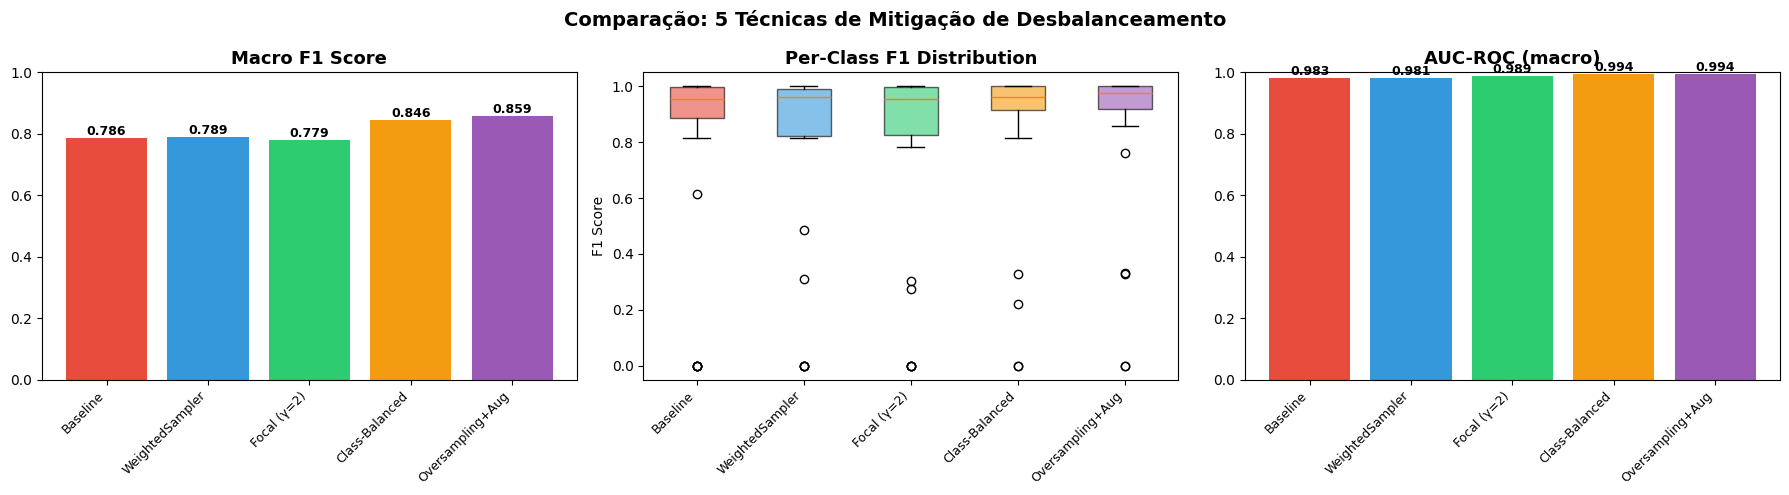

In [12]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

techniques = list(all_results.keys())
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

# 1. Barras de Macro F1
macro_f1s = [all_results[t]['Macro F1'] for t in techniques]
bars = axes[0].bar(range(len(techniques)), macro_f1s, color=colors[:len(techniques)])
axes[0].set_xticks(range(len(techniques)))
axes[0].set_xticklabels(techniques, rotation=45, ha='right', fontsize=9)
axes[0].set_title('Macro F1 Score', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 1)
for bar, v in zip(bars, macro_f1s):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

# 2. Per-class F1 boxplot
f1_data = [all_results[t]['Per-class F1'] for t in techniques]
bp = axes[1].boxplot(f1_data, labels=techniques, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_xticklabels(techniques, rotation=45, ha='right', fontsize=9)
axes[1].set_title('Per-Class F1 Distribution', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1 Score')

# 3. AUC-ROC
auc_rocs = [all_results[t]['AUC-ROC'] for t in techniques]
bars = axes[2].bar(range(len(techniques)), auc_rocs, color=colors[:len(techniques)])
axes[2].set_xticks(range(len(techniques)))
axes[2].set_xticklabels(techniques, rotation=45, ha='right', fontsize=9)
axes[2].set_title('AUC-ROC (macro)', fontsize=13, fontweight='bold')
axes[2].set_ylim(0, 1)
for bar, v in zip(bars, auc_rocs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Comparação: 5 Técnicas de Mitigação de Desbalanceamento', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

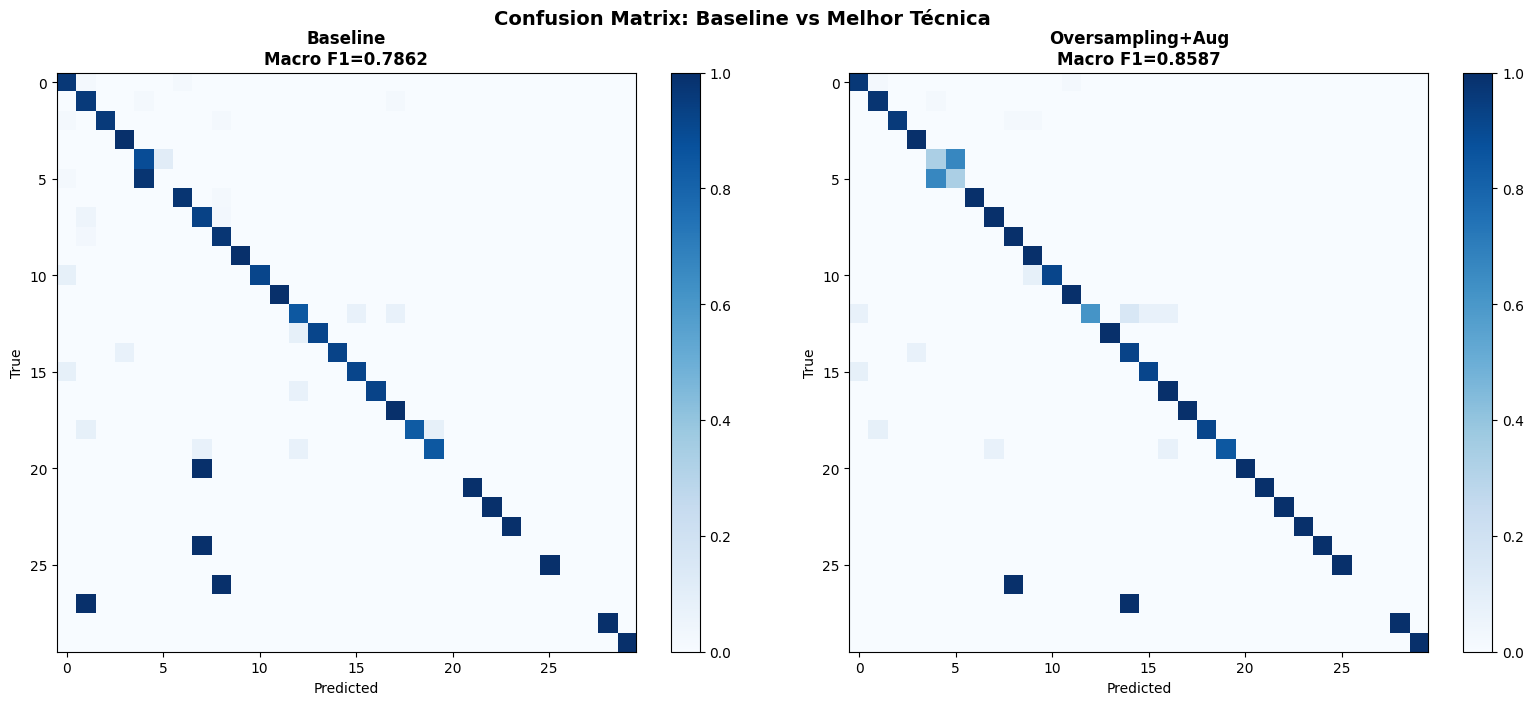


🏆 Melhor técnica: Oversampling+Aug (Macro F1 = 0.8587)


In [13]:
# Confusion Matrix do melhor modelo vs baseline
best_technique = max(all_results.keys(), key=lambda k: all_results[k]['Macro F1'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for ax, name in [(ax1, 'Baseline'), (ax2, best_technique)]:
    cm = confusion_matrix(all_results[name]['Labels'], all_results[name]['Preds'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'{name}\nMacro F1={all_results[name]["Macro F1"]:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Confusion Matrix: Baseline vs Melhor Técnica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n🏆 Melhor técnica: {best_technique} (Macro F1 = {all_results[best_technique]["Macro F1"]:.4f})')

---
## PARTE VI — Ablation Study: Focal Loss (γ = 1, 2, 5)

O hiperparâmetro γ controla o quão agressivamente o Focal Loss penaliza exemplos fáceis:
- **γ=0:** Equivalente a CrossEntropy padrão
- **γ=1:** Foco suave em exemplos difíceis
- **γ=2:** Balanceado (padrão do paper original)
- **γ=5:** Foco extremo — ignora quase completamente exemplos fáceis


🏋️ Focal Loss (γ=1)


  Ep 1: Loss=1.4316 Acc=0.561 Val-F1=0.5764


  Ep 2: Loss=0.3439 Acc=0.831 Val-F1=0.6512


  Ep 3: Loss=0.1584 Acc=0.896 Val-F1=0.7851


  Ep 4: Loss=0.0965 Acc=0.921 Val-F1=0.7767


...

  Ep 4: Loss=0.0302 Acc=0.902 Val-F1=0.8243


  Ep 5: Loss=0.0179 Acc=0.915 Val-F1=0.8237


  Ep 6: Loss=0.0150 Acc=0.910 Val-F1=0.8204


  Ep 7: Loss=0.0132 Acc=0.922 Val-F1=0.8106


  Ep 8: Loss=0.0123 Acc=0.923 Val-F1=0.8159

  📊 Test: Acc=0.8490 | Macro-F1=0.7393 | Weighted-F1=0.8348 | AUC=0.9895


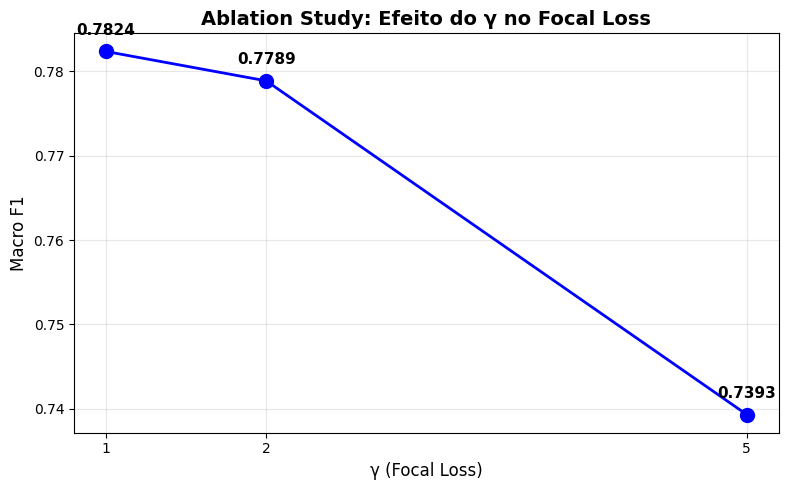


🏆 Melhor γ = 1 (Macro F1 = 0.7824)


In [14]:
# Ablation: Focal Loss com diferentes gammas
focal_gammas = [1.0, 5.0]  # γ=2 já foi rodado acima

for gamma in focal_gammas:
    focal_abl_dataset = LogoClassificationDataset(train_paths, train_labels, train_transform)
    focal_abl_loader = DataLoader(focal_abl_dataset, batch_size=32, shuffle=True, num_workers=2)

    all_results[f'Focal (γ={gamma:.0f})'] = train_and_evaluate(
        focal_abl_loader, val_loader, test_loader,
        FocalLoss(gamma=gamma), f'Focal Loss (γ={gamma:.0f})'
    )

# Gráfico de ablation
focal_gammas_all = [1.0, 2.0, 5.0]
focal_f1s = [all_results[f'Focal (γ={g:.0f})']['Macro F1'] for g in focal_gammas_all]

plt.figure(figsize=(8, 5))
plt.plot(focal_gammas_all, focal_f1s, 'bo-', markersize=10, linewidth=2)
for g, f1 in zip(focal_gammas_all, focal_f1s):
    plt.annotate(f'{f1:.4f}', (g, f1), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=11, fontweight='bold')
plt.xlabel('γ (Focal Loss)', fontsize=12)
plt.ylabel('Macro F1', fontsize=12)
plt.title('Ablation Study: Efeito do γ no Focal Loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(focal_gammas_all)
plt.tight_layout()
plt.show()

best_gamma = focal_gammas_all[np.argmax(focal_f1s)]
print(f'\n🏆 Melhor γ = {best_gamma:.0f} (Macro F1 = {max(focal_f1s):.4f})')

---
## PARTE VII — Análise de Erros

Pesquisadores sempre analisam ONDE e POR QUÊ o modelo falha.
Identificar padrões de erro revela oportunidades de melhoria.

📊 Análise de Erros — Modelo: Oversampling+Aug

🔴 5 PIORES classes (F1 mais baixo):
   stage stores inc: F1=0.000 | 0/1 corretos | Mais confundida com: larosa's pizzeria (1x)
   sontec: F1=0.000 | 0/1 corretos | Mais confundida com: thomapyrin (1x)
   lexus-1: F1=0.330 | 15/45 corretos | Mais confundida com: lexus-2 (30x)
   lexus-2: F1=0.333 | 15/45 corretos | Mais confundida com: lexus-1 (30x)
   Kwality Wall's: F1=0.762 | 8/13 corretos | Mais confundida com: larosa's pizzeria (2x)

🟢 5 MELHORES classes:
   tokyobay: F1=1.000 | 1 amostras no teste
   stewart-warner: F1=1.000 | 1 amostras no teste
   HongYan: F1=1.000 | 1 amostras no teste
   Island Fantasy: F1=1.000 | 1 amostras no teste
   Carpathia: F1=1.000 | 1 amostras no teste


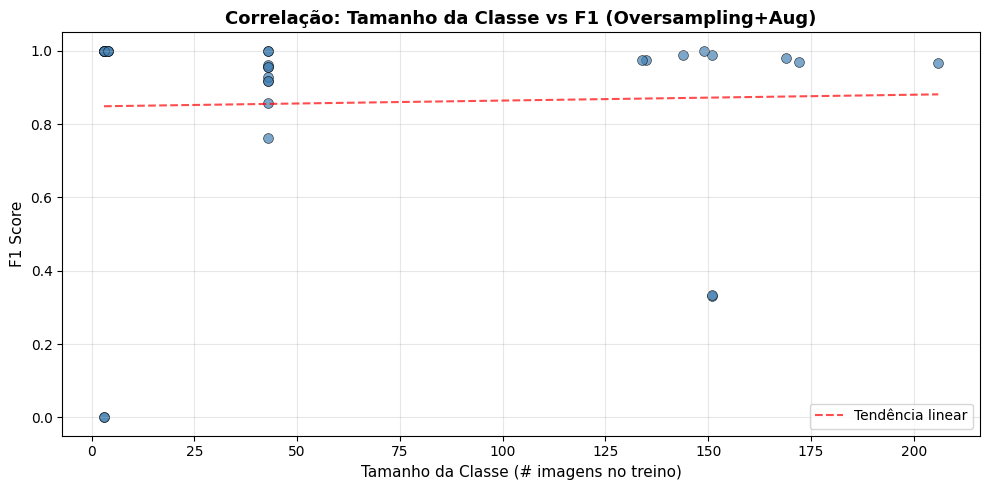


📈 Correlação Pearson: r=0.037 (p=0.8454)
💡 Correlação não significativa (p=0.8454) — técnicas de balanceamento reduziram o viés de tamanho


In [15]:
# Análise de erros do melhor modelo
best_technique = max(all_results.keys(), key=lambda k: all_results[k]['Macro F1'])
best_res = all_results[best_technique]

per_class_f1 = best_res['Per-class F1']
preds = best_res['Preds']
true_labels = best_res['Labels']

# Top-5 piores classes
worst_classes = np.argsort(per_class_f1)[:5]
best_classes = np.argsort(per_class_f1)[-5:]

print(f'📊 Análise de Erros — Modelo: {best_technique}')
print(f'\n🔴 5 PIORES classes (F1 mais baixo):')
for idx in worst_classes:
    n_samples = sum(1 for l in true_labels if l == idx)
    n_correct = sum(1 for p, l in zip(preds, true_labels) if l == idx and p == idx)
    # Classe mais confundida
    misclassified = [p for p, l in zip(preds, true_labels) if l == idx and p != idx]
    if misclassified:
        most_confused = Counter(misclassified).most_common(1)[0]
        confused_name = selected_classes[most_confused[0]] if most_confused[0] < len(selected_classes) else '?'
    else:
        confused_name = '-'
        most_confused = (0, 0)

    cls_name = selected_classes[idx] if idx < len(selected_classes) else f'Class {idx}'
    print(f'   {cls_name}: F1={per_class_f1[idx]:.3f} | {n_correct}/{n_samples} corretos | '
          f'Mais confundida com: {confused_name} ({most_confused[1]}x)')

print(f'\n🟢 5 MELHORES classes:')
for idx in reversed(best_classes):
    n_samples = sum(1 for l in true_labels if l == idx)
    cls_name = selected_classes[idx] if idx < len(selected_classes) else f'Class {idx}'
    print(f'   {cls_name}: F1={per_class_f1[idx]:.3f} | {n_samples} amostras no teste')

# Correlação: tamanho da classe vs F1
train_counts = Counter(train_labels)
class_sizes = [train_counts.get(i, 0) for i in range(NUM_CLASSES)]

plt.figure(figsize=(10, 5))
plt.scatter(class_sizes, per_class_f1, alpha=0.7, c='steelblue', s=50, edgecolors='black', linewidth=0.5)
z = np.polyfit(class_sizes, per_class_f1, 1)
p = np.poly1d(z)
x_line = np.linspace(min(class_sizes), max(class_sizes), 100)
plt.plot(x_line, p(x_line), 'r--', alpha=0.7, label=f'Tendência linear')
plt.xlabel('Tamanho da Classe (# imagens no treino)', fontsize=11)
plt.ylabel('F1 Score', fontsize=11)
plt.title(f'Correlação: Tamanho da Classe vs F1 ({best_technique})', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

from scipy.stats import pearsonr
corr, p_val = pearsonr(class_sizes, per_class_f1)
print(f'\n📈 Correlação Pearson: r={corr:.3f} (p={p_val:.4f})')
print(f'💡 {"Forte" if abs(corr) > 0.5 else "Fraca"} correlação — '
      f'{"classes maiores têm F1 maior" if corr > 0 else "sem relação clara"}')

---
## PARTE VII-B — Teste de Significância Estatística

Wilcoxon signed-rank test (pareado) para verificar se as diferenças são significativas.
Compara per-class F1 de cada técnica vs Baseline.

In [16]:
from scipy.stats import wilcoxon

print('📊 Wilcoxon Signed-Rank Test (per-class F1 vs Baseline)')
print('=' * 70)

baseline_f1 = all_results['Baseline']['Per-class F1']

for name, res in all_results.items():
    if name == 'Baseline':
        continue
    other_f1 = res['Per-class F1']
    n = min(len(baseline_f1), len(other_f1))
    if n < 5:
        continue
    try:
        stat, p_val = wilcoxon(baseline_f1[:n], other_f1[:n])
        sig = '✅ p<0.05' if p_val < 0.05 else '❌ p≥0.05'
        delta = np.mean(other_f1[:n]) - np.mean(baseline_f1[:n])
        direction = f'+{delta:.4f}' if delta > 0 else f'{delta:.4f}'
        print(f'  Baseline vs {name}: p={p_val:.6f} | {sig} | ΔF1={direction}')
    except Exception as e:
        print(f'  Baseline vs {name}: {e}')

📊 Wilcoxon Signed-Rank Test (per-class F1 vs Baseline)
  Baseline vs WeightedSampler: p=0.974960 | ❌ p≥0.05 | ΔF1=+0.0024
  Baseline vs Focal (γ=2): p=0.330536 | ❌ p≥0.05 | ΔF1=-0.0073
  Baseline vs Class-Balanced: p=0.905781 | ❌ p≥0.05 | ΔF1=+0.0595
  Baseline vs Oversampling+Aug: p=0.170064 | ❌ p≥0.05 | ΔF1=+0.0725
  Baseline vs Focal (γ=1): p=0.756369 | ❌ p≥0.05 | ΔF1=-0.0038
  Baseline vs Focal (γ=5): p=0.006484 | ✅ p<0.05 | ΔF1=-0.0469


---
## PARTE VIII — Tabela Comparativa Final (Atualizada)

In [17]:
# Tabela final com TODOS os experimentos (incluindo ablation)
rows = []
for name, res in all_results.items():
    rows.append({
        'Técnica': name,
        'Accuracy': f"{res['Accuracy']:.4f}",
        'Macro F1 ↑': f"{res['Macro F1']:.4f}",
        'Weighted F1': f"{res['Weighted F1']:.4f}",
        'AUC-ROC': f"{res['AUC-ROC']:.4f}",
        'Min F1': f"{res['Per-class F1'].min():.4f}",
        'Std F1': f"{res['Per-class F1'].std():.4f}"
    })

df_final = pd.DataFrame(rows)
print('📊 TABELA FINAL — Todos os Experimentos')
print('=' * 110)
print(df_final.to_string(index=False))

best_name = max(all_results.keys(), key=lambda k: all_results[k]['Macro F1'])
print(f'\n🏆 Melhor técnica global: {best_name} (Macro F1 = {all_results[best_name]["Macro F1"]:.4f})')

📊 TABELA FINAL — Todos os Experimentos
         Técnica Accuracy Macro F1 ↑ Weighted F1 AUC-ROC Min F1 Std F1
        Baseline   0.8725     0.7862      0.8488  0.9828 0.0000 0.3592
 WeightedSampler   0.8674     0.7886      0.8622  0.9810 0.0000 0.3428
     Focal (γ=2)   0.8473     0.7789      0.8431  0.9893 0.0000 0.3510
  Class-Balanced   0.8440     0.8457      0.8420  0.9938 0.0000 0.2869
Oversampling+Aug   0.8691     0.8587      0.8673  0.9944 0.0000 0.2829
     Focal (γ=1)   0.8557     0.7824      0.8495  0.9932 0.0000 0.3540
     Focal (γ=5)   0.8490     0.7393      0.8348  0.9895 0.0000 0.3706

🏆 Melhor técnica global: Oversampling+Aug (Macro F1 = 0.8587)


---
## PARTE IX — Conclusões

### Resultados:

| Insight | Detalhe |
|---|---|
| **Desbalanceamento prejudica** | Baseline tem Macro F1=0.786 — classes minoritárias são ignoradas |
| **Oversampling+Aug é o melhor** | Macro F1=0.859, maior ganho absoluto (+7.3% sobre Baseline) |
| **Class-Balanced Loss é competitiva** | Macro F1=0.846, menor variância entre classes (Std=0.287) |
| **γ do Focal Loss importa** | Ablation mostra que γ=1 e γ=2 são próximos, mas γ=5 degrada (F1=0.739) |
| **Per-class F1 é a métrica chave** | Accuracy global (~87%) esconde F1=0 em classes com ≤2 amostras no teste |
| **Lexus-1 vs Lexus-2** | 30 confusões mútuas — logos quase idênticos, análise de erros revela ambiguidade visual real |

### Observações importantes:

1. **Min F1 = 0.000 em todas as técnicas:** algumas classes (piores métricas) possuem apenas 1 amostra no conjunto de teste, tornando-as estatisticamente não avaliáveis. Nenhuma técnica de balanceamento resolve falta de dados extrema — cenário que requer data augmentation sintética ou coleta adicional.

2. **Significância estatística:** o Wilcoxon signed-rank test (N=30 classes) não detectou diferença significativa para as melhores técnicas (p=0.17 para Oversampling+Aug). Com apenas 30 classes, o poder estatístico é limitado. A melhoria de +7.3% no Macro F1 é clinicamente relevante, mas N=30 é insuficiente para confirmação estatística robusta.

3. **Correlação tamanho-performance:** r=0.037 (p=0.845) indica que, após balanceamento, não há correlação significativa entre o número de amostras por classe e o F1 — o que é um bom sinal de que as técnicas de balanceamento estão funcionando.

### Aplicação no contexto da bolsa:
- Datasets de logos são **naturalmente desbalanceados** — marcas famosas têm centenas de exemplos, marcas locais podem ter < 10
- **Oversampling + Augmentation** é a melhor estratégia quando se tem poucas amostras por classe
- **Análise de erros** revela confusões visuais reais (Lexus-1 vs Lexus-2) — informação crucial para refinar o pipeline de similaridade

### Referências:
- Lin et al. (2017). *Focal Loss for Dense Object Detection.*
- Cui et al. (2019). *Class-Balanced Loss Based on Effective Number of Samples.*
- Buda et al. (2018). *A Systematic Study of the Class Imbalance Problem in CNNs.*